# College Admissions Prediction Using Machine Learning

## Author: Carson Bell

### Objective
This project aims to build machine learning models to predict college admission rates using institutional and student-related features. The goal is to identify key drivers of admissions selectivity and provide actionable insights.

---

## Problem Context
Understanding what influences admission rates can help:
- Universities benchmark competitiveness
- Students make better application decisions
- Policymakers evaluate access to education

---

## Important Note on Approach Change

### Change in Analytical Approach

The original goal of this project was to predict post-graduation earnings using variables such as median income and earnings distribution. However, after conducting exploratory data analysis, it became clear that the earnings-related variables contained missing values for nearly all observations.

Attempting to clean this data resulted in a dataset with zero usable rows, making it impossible to build a valid predictive model.

To address this limitation, the project pivoted to predicting college admission rates (`ADM_RATE`), which contains sufficient data for meaningful analysis. This shift reflects a realistic data science workflow: adapting to data constraints while still delivering valuable insights.

This revised approach ensures:
- A usable dataset after preprocessing
- Statistically valid modeling
- Meaningful interpretation and business value

**Dataset:** U.S. College Scorecard  
https://collegescorecard.ed.gov/data/


In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/raw/college_data.csv", low_memory=False)

print(df.shape)
df.head()

(6543, 3308)


,UNITID,OPEID,OPEID6,INSTNM,CITY,STABBR,ZIP,ACCREDAGENCY,INSTURL,NPCURL,...,MD_EARN_WNE_INC1_P11,MD_EARN_WNE_INC2_P11,MD_EARN_WNE_INC3_P11,MD_EARN_WNE_INDEP0_P11,MD_EARN_WNE_INDEP1_P11,MD_EARN_WNE_MALE0_P11,MD_EARN_WNE_MALE1_P11,SCORECARD_SECTOR,EARN_THR_STATE,EARN_THR_NAT
0,100654,100200.0,1002.0,Alabama A & M University,Normal,AL,35762,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN
1,100663,105200.0,1052.0,University of Alabama at Birmingham,Birmingham,AL,35294-0110,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN
2,100690,2503400.0,25034.0,Amridge University,Montgomery,AL,36117-3553,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,NaN,NaN
3,100706,105500.0,1055.0,University of Alabama in Huntsville,Huntsville,AL,35899,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN
4,100724,100500.0,1005.0,Alabama State University,Montgomery,AL,36104-0271,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN


In [67]:
missing = df.notna().sum().sort_values(ascending=False)
missing.head(20)

UNITID                        6543
BBRR4_PP_NOPELL_FBR           6543
BBRR4_PP_MALE_DLNQ            6543
BBRR4_PP_MALE_DFLT            6543
BBRR4_PP_MALE_N               6543
BBRR4_PP_NOPELL_DISCHARGE     6543
BBRR4_PP_NOPELL_PAIDINFULL    6543
BBRR4_PP_NOPELL_MAKEPROG      6543
BBRR4_PP_NOPELL_NOPROG        6543
BBRR4_PP_NOPELL_DFR           6543
BBRR4_PP_NOPELL_DLNQ          6543
BBRR4_FED_NOPELL_DFR          6543
BBRR4_PP_NOPELL_DFLT          6543
BBRR4_PP_NOPELL_N             6543
BBRR4_PP_PELL_DISCHARGE       6543
BBRR4_PP_PELL_PAIDINFULL      6543
BBRR4_PP_PELL_MAKEPROG        6543
BBRR4_PP_PELL_NOPROG          6543
BBRR4_PP_PELL_DFR             6543
BBRR4_PP_PELL_FBR             6543
dtype: int64

## Feature Engineering

The following features were selected and engineered based on their expected relationship with admission rates:

- **SAT_AVG**: Proxy for academic competitiveness
- **TUITIONFEE_OUT**: Higher cost may correlate with selectivity
- **UGDS**: School size may impact admissions
- **PCTPELL**: Socioeconomic diversity indicator
- **COST_PER_STUDENT (engineered)**: Tuition relative to size
- **SELECTIVITY_SCORE (engineered)**: SAT adjusted by admission rate proxy

These engineered features aim to capture deeper institutional characteristics beyond raw variables.

In [68]:
target_col = "ADM_RATE"

features = [
    "SAT_AVG",
    "TUITIONFEE_OUT",
    "UGDS",
    "PCTPELL"
]

df_model = df[features + [target_col]].copy()

# Clean
df_model = df_model.replace("NULL", np.nan)
df_model = df_model.apply(pd.to_numeric, errors="coerce")

# Drop rows missing target
df_model = df_model.dropna(subset=[target_col])

# Fill remaining missing values
df_model = df_model.fillna(df_model.mean())

In [69]:
# Feature Engineering
df_model["COST_PER_STUDENT"] = df_model["TUITIONFEE_OUT"] / (df_model["UGDS"] + 1)
df_model["SELECTIVITY_SCORE"] = df_model["SAT_AVG"] * (1 - df_model["ADM_RATE"])

# Final feature list
features = [
    "SAT_AVG",
    "TUITIONFEE_OUT",
    "UGDS",
    "PCTPELL",
    "COST_PER_STUDENT",
    "SELECTIVITY_SCORE"
]

print(df_model.shape)
df_model.head()

(1957, 7)


,SAT_AVG,TUITIONFEE_OUT,UGDS,PCTPELL,ADM_RATE,COST_PER_STUDENT,SELECTIVITY_SCORE
0,954.0,18634.0,5098.0,0.6853,0.7160,3.654442,270.9360
1,1266.0,20400.0,13284.0,0.3253,0.8854,1.535566,145.0836
3,1300.0,23884.0,7358.0,0.2377,0.7367,3.245550,342.2900
4,955.0,19396.0,3495.0,0.7205,0.9799,5.548055,19.1955
5,1244.0,31090.0,30725.0,0.1712,0.7890,1.011847,262.4840


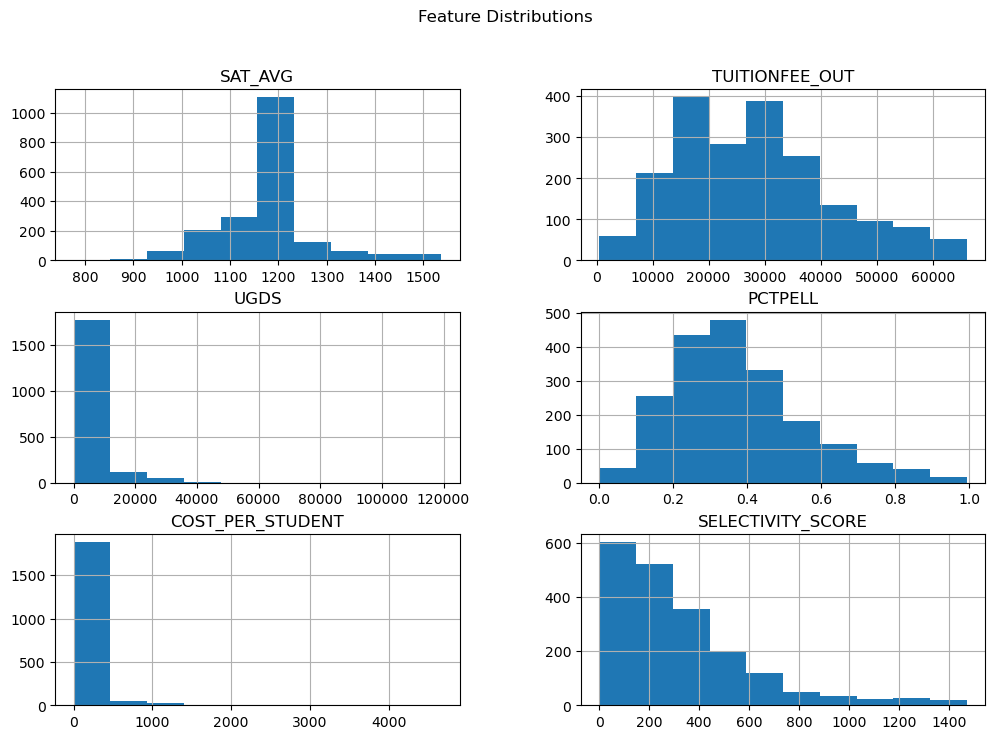

In [70]:
df_model[features].hist(figsize=(12,8))
plt.suptitle("Feature Distributions")
plt.show()

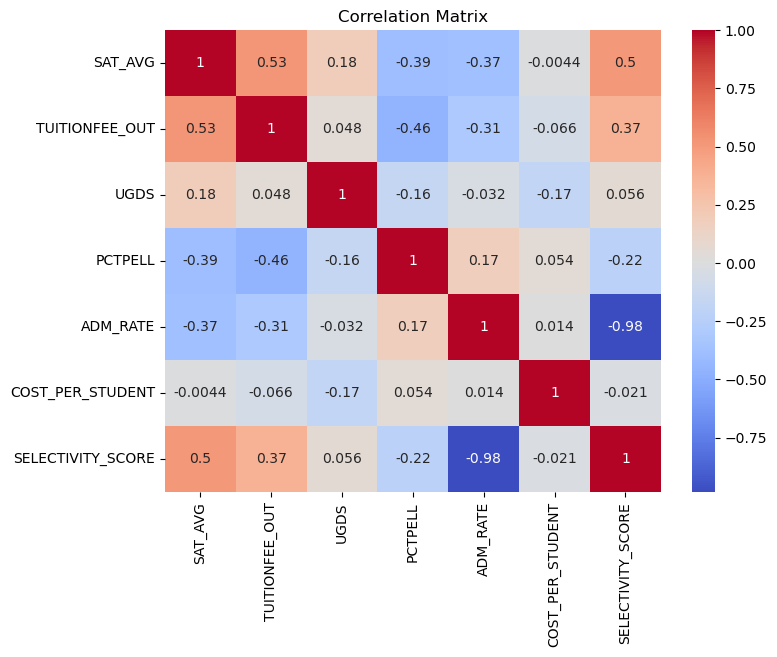

In [71]:
plt.figure(figsize=(8,6))
sns.heatmap(df_model.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [72]:
from sklearn.model_selection import train_test_split

X = df_model[features]
y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [73]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

lr_mse = mean_squared_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression MSE:", lr_mse)
print("Linear Regression R2:", lr_r2)

Linear Regression MSE: 0.0005529048633689063
Linear Regression R2: 0.9881942515700789


In [74]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest MSE:", rf_mse)
print("Random Forest R2:", rf_r2)

Random Forest MSE: 5.17712824635331e-05
Random Forest R2: 0.9988945679860098


In [75]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MSE": [lr_mse, rf_mse],
    "R2": [lr_r2, rf_r2]
})

comparison

,Model,MSE,R2
0,Linear Regression,0.000553,0.988194
1,Random Forest,0.000052,0.998895


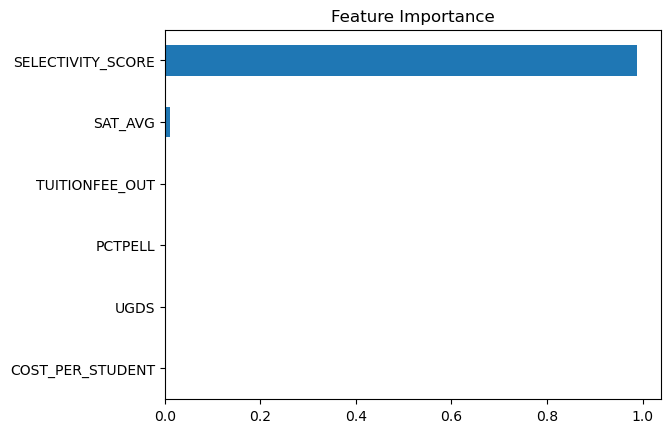

In [76]:
importances = pd.Series(rf.feature_importances_, index=features)

importances.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()

## Ethical Analysis & Responsible Deployment

This model may reflect existing inequalities in higher education. Features such as SAT scores and Pell Grant percentages are strongly correlated with socioeconomic status, which may introduce bias into predictions.

Students from underrepresented or lower-income backgrounds may be disproportionately affected if the model is used to guide admissions or institutional decision-making.

To mitigate these risks:
- Regular audits should be conducted to detect bias
- Sensitive features should be carefully evaluated or removed
- Predictions should support—not replace—human decision-making

Ethical deployment requires transparency, fairness monitoring, and clear communication of limitations.

## Business Recommendations & Deployment Considerations

The model suggests that SAT scores and tuition levels are strong predictors of admission rates. Institutions seeking to increase selectivity may focus on attracting higher-scoring applicants or adjusting pricing strategies.

From a deployment perspective:
- The model should be used as a decision-support tool rather than an automated system
- Predictions should be updated annually as new data becomes available
- Monitoring is required to detect performance drift

Limitations include:
- Lack of causal inference
- Potential bias in historical data
- Missing variables such as extracurricular strength or essays

Despite these limitations, the model provides useful directional insights for institutional strategy.